In [2]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


In [3]:
# Fashion-MNIST dataset
(train_images, train_labels), (test_images, test_labels) = datasets.fashion_mnist.load_data()

print('Train images:', train_images.shape)
print('Test images :', test_images.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28)
Test images : (10000, 28, 28)


In [4]:
train_images.shape


(60000, 28, 28)

In [5]:
# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Add the channel dimension for CNN input: (28, 28, 1)
train_images = np.expand_dims(train_images, axis=-1)
test_images = np.expand_dims(test_images, axis=-1)

print('Train images after preprocessing:', train_images.shape)
print('Test images after preprocessing :', test_images.shape)


Train images after preprocessing: (60000, 28, 28, 1)
Test images after preprocessing : (10000, 28, 28, 1)


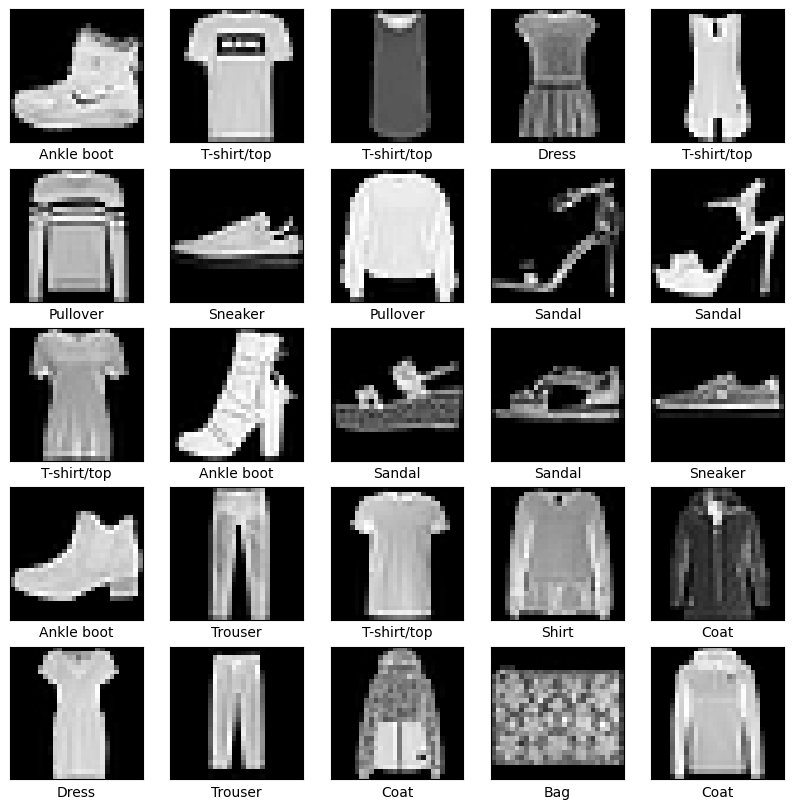

In [6]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i].squeeze(), cmap='gray')
    plt.xlabel(class_names[train_labels[i]])
plt.show()


In [20]:
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10)
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,802 (3.42 MB)

 Trainable params: 897,354 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
# Convert labels to one-hot encoding
train_labels_categorical = to_categorical(train_labels, num_classes=10)
test_labels_categorical = to_categorical(test_labels, num_classes=10)


In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        from_logits=True
    ),
    metrics=['accuracy']
)

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=4,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [26]:
history = model.fit(
    train_images,
    train_labels_categorical,

    epochs=20,

    validation_split=0.1,

    batch_size=16,

    callbacks=callbacks,

    shuffle=True
)

Epoch 1/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.8490 - loss: 0.4309 - val_accuracy: 0.8553 - val_loss: 0.4338 - learning_rate: 0.0010
Epoch 2/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8928 - loss: 0.2987 - val_accuracy: 0.8907 - val_loss: 0.2879 - learning_rate: 0.0010
Epoch 3/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9064 - loss: 0.2561 - val_accuracy: 0.8852 - val_loss: 0.3618 - learning_rate: 0.0010
Epoch 4/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9159 - loss: 0.2326 - val_accuracy: 0.9083 - val_loss: 0.2567 - learning_rate: 0.0010
Epoch 5/20
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9257 - loss: 0.2025 - val_accuracy: 0.8947 - val_loss: 0.3040 - learning_rate: 0.0010
Epoch 6/20
3371/3375 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9313 - loss: 0.1850
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.931

In [27]:
best_val_acc = max(history.history["val_accuracy"])

print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Validation Accuracy: {best_val_acc * 100:.2f}%")

Best Validation Accuracy: 0.9343
Best Validation Accuracy: 93.43%


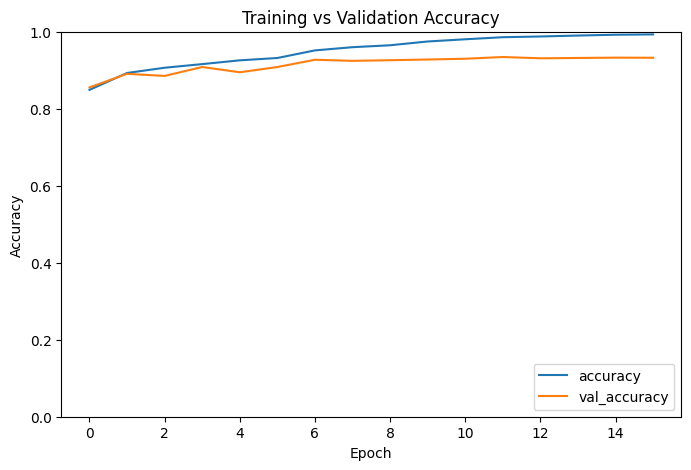

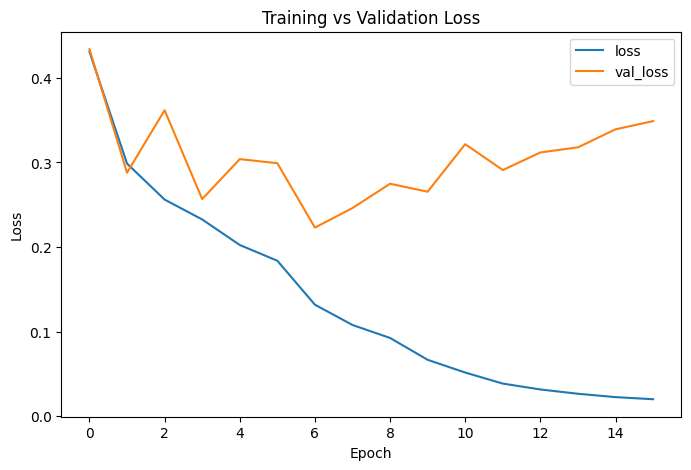

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9326 - loss: 0.3223
Test Accuracy: 93.26%
Test Loss: 0.3223


In [28]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')
plt.show()

# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(
    test_images,
    test_labels_categorical,
    verbose=1
)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

In [29]:
# Predictions and classification report
logits = model.predict(test_images, verbose=0)
predicted_labels = np.argmax(logits, axis=1)

print('Classification Report:')
print(classification_report(test_labels, predicted_labels, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.89      0.89      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.88      0.92      0.90      1000
       Dress       0.93      0.94      0.94      1000
        Coat       0.90      0.89      0.89      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.82      0.77      0.80      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



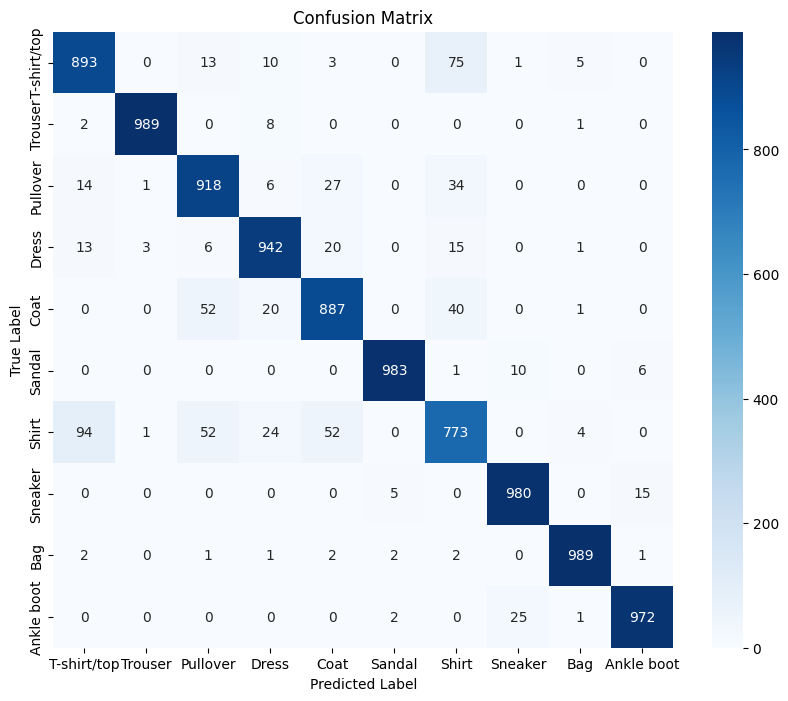

In [30]:
# Confusion Matrix
cm = confusion_matrix(test_labels, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [31]:
# Save the trained model
model.save('cnn_fashion_mnist.keras')
model.save_weights('cnn_fashion_mnist.weights.h5')

print('Model saved successfully!')
print('Full model  : cnn_fashion_mnist.keras')
print('Model weights: cnn_fashion_mnist.weights.h5')


Model saved successfully!
Full model  : cnn_fashion_mnist.keras
Model weights: cnn_fashion_mnist.weights.h5


In [32]:
# Download the model to your computer (Google Colab)
from google.colab import files

files.download('cnn_fashion_mnist.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>